In [1]:
# Cell 1: Plot chip centers with coastline (fix PROJ error)
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
import geopandas as gpd
import glob
import os

# ======= Train or Val ============
train_val = 'validation' # 'validation', 'training'
# ======= Train or Val ============

openet_dir = '/discover/nobackup/ejalilva/data/prithvi/openet_tiles_int_waterfixed_2022/'
base_dir = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/'

if train_val == 'training':
    chips_folder = os.path.join(base_dir,'training_chips')
else:
    chips_folder = os.path.join(base_dir,'validation_chips')
output_dir = os.path.join(openet_dir,f'ir_{train_val}_chips')
os.makedirs(output_dir, exist_ok=True)

In [2]:
# Get all chips and transform bounds instead of points

chip_files = glob.glob(f"{chips_folder}/chip*mask.tif")

lons, lats = [], []
for i, chip_file in enumerate(chip_files):
    with rasterio.open(chip_file) as src:
        # Use transform_bounds instead of transform to avoid PROJ error
        bounds_4326 = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
        center_lon = (bounds_4326[0] + bounds_4326[2]) / 2
        center_lat = (bounds_4326[1] + bounds_4326[3]) / 2
        lons.append(center_lon)
        lats.append(center_lat)
    
    if (i + 1) % 50 == 0 or (i + 1) == len(chip_files):
        print(f"Processed {i+1}/{len(chip_files)} chips")

Processed 50/771 chips
Processed 100/771 chips
Processed 150/771 chips
Processed 200/771 chips
Processed 250/771 chips
Processed 300/771 chips
Processed 350/771 chips
Processed 400/771 chips
Processed 450/771 chips
Processed 500/771 chips
Processed 550/771 chips
Processed 600/771 chips
Processed 650/771 chips
Processed 700/771 chips
Processed 750/771 chips
Processed 771/771 chips


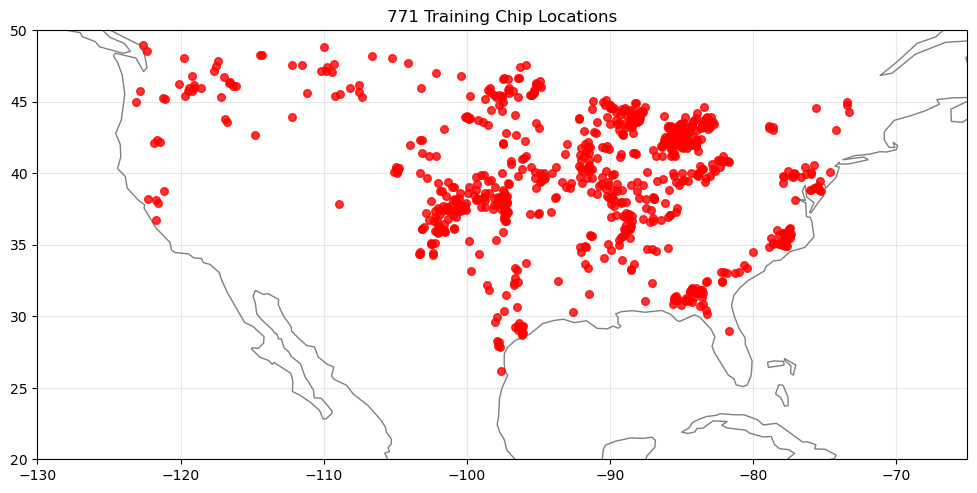

Plotted 771 chips


In [3]:
# Plot with coastlines
fig, ax = plt.subplots(figsize=(12, 8))

# Plot coastlines
coastline_dir = '/discover/nobackup/ejalilva/data/coastline'
coast_shp = os.path.join(coastline_dir, 'ne_110m_coastline.shp')
coastline = gpd.read_file(coast_shp)
coastline.plot(ax=ax, edgecolor='gray', linewidth=1)

# Plot chip centers
ax.scatter(lons, lats, c='red', s=30, alpha=0.8, zorder=5)

ax.set_xlim(-130, -65)
ax.set_ylim(20, 50)
ax.set_title(f'{len(chip_files)} Training Chip Locations')
ax.grid(True, alpha=0.3)
plt.show()

print(f"Plotted {len(chip_files)} chips")

# finding overlapping chips with each openet-irr-label tile

In [4]:
openet_dir = '/discover/nobackup/ejalilva/data/prithvi/openet_tiles_int_waterfixed_2022/'
openet_files = sorted(glob.glob(f"{openet_dir}/irr_*.tif"))
overlaps = {}
openet_files
count = 0
for openet_file in openet_files:
    os.path.basename(openet_file)
    openet_name = os.path.basename(openet_file)
    with rasterio.open(openet_file) as src:
        bounds = src.bounds
    
    intersecting_chips = []
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        if bounds.left <= lon <= bounds.right and bounds.bottom <= lat <= bounds.top:
            intersecting_chips.append(os.path.basename(chip_files[i]))
    
    overlaps[openet_name] = intersecting_chips
    print(f"{openet_name}: {len(intersecting_chips)} intersecting chips")
    count += len(intersecting_chips)
print('total number of intersecting chips: ', count)

irr_composite_2022_r0_c3.tif: 0 intersecting chips
irr_composite_2022_r0_c4.tif: 0 intersecting chips
irr_composite_2022_r0_c5.tif: 17 intersecting chips
irr_composite_2022_r0_c6.tif: 0 intersecting chips
irr_composite_2022_r0_c7.tif: 0 intersecting chips
irr_composite_2022_r1_c0.tif: 0 intersecting chips
irr_composite_2022_r1_c1.tif: 0 intersecting chips
irr_composite_2022_r1_c2.tif: 0 intersecting chips
irr_composite_2022_r1_c3.tif: 0 intersecting chips
irr_composite_2022_r1_c4.tif: 6 intersecting chips
irr_composite_2022_r1_c5.tif: 14 intersecting chips
irr_composite_2022_r1_c6.tif: 10 intersecting chips
irr_composite_2022_r1_c7.tif: 20 intersecting chips
irr_composite_2022_r2_c0.tif: 5 intersecting chips
irr_composite_2022_r2_c1.tif: 0 intersecting chips
irr_composite_2022_r2_c2.tif: 0 intersecting chips
irr_composite_2022_r2_c3.tif: 1 intersecting chips
irr_composite_2022_r2_c4.tif: 71 intersecting chips
irr_composite_2022_r2_c5.tif: 59 intersecting chips
irr_composite_2022_r2_c6.

In [7]:
import pandas as pd
from osgeo import gdal
import rasterio
import os
import numpy as np

# Main loop
all_processed_chips = []  # Track ALL processed chips

for openet_file in openet_files:  # openet_files are full paths from glob
    tile_name = os.path.basename(openet_file)  # Get basename for overlaps lookup

    # Check if this tile has intersecting chips
    if tile_name not in overlaps:
        print(f"Skipping {tile_name} - not in overlaps")
        continue
        
    intersecting_chips = overlaps[tile_name]
    
    if not intersecting_chips:
        print(f"Skipping {tile_name} - no intersecting chips")
        continue
    
    print(f"\n=== Processing {tile_name} ===")
    print(f"Processing {len(intersecting_chips)} chips")
    
    for i, chip_name in enumerate(intersecting_chips):
        chip_path = os.path.join(chips_folder, chip_name)
        
        try:
            # Get CHIP properties for alignment
            chip_ds = gdal.Open(chip_path)
            if chip_ds is None:
                print(f"  Could not open {chip_name}")
                continue
                
            chip_proj = chip_ds.GetProjection()
            chip_gt = chip_ds.GetGeoTransform()
            x_pixels, y_pixels = chip_ds.RasterXSize, chip_ds.RasterYSize
            
            # Calculate bounds
            minx, maxy = chip_gt[0], chip_gt[3]
            pixel_size_x, pixel_size_y = abs(chip_gt[1]), abs(chip_gt[5])
            maxx = minx + (x_pixels * pixel_size_x)
            miny = maxy - (y_pixels * pixel_size_y)
            chip_ds = None  # Close dataset
            
            # Get profile from rasterio for saving
            with rasterio.open(chip_path) as chip_src:
                profile = chip_src.profile.copy()
            
            # Align openET to CHIP
            temp_output = f"/tmp/temp_openet_{os.getpid()}_{i}.tif"  # Add PID to avoid conflicts
            warp_options = gdal.WarpOptions(
                outputBounds=[minx, miny, maxx, maxy],
                width=x_pixels, 
                height=y_pixels,
                dstSRS=chip_proj,
                resampleAlg=gdal.GRA_NearestNeighbour,
                dstNodata=-1
            )
            result = gdal.Warp(temp_output, openet_file, options=warp_options)
            
            if result is None:
                print(f"  Warp failed for {chip_name}")
                continue
            result = None  # Close gdal dataset
            
            # Load aligned openET (all 3 bands)
            with rasterio.open(temp_output) as openet_src:
                label_data = openet_src.read(1)
                summer_et_data = openet_src.read(2)
                water_deficit_data = openet_src.read(3)
                cdl_data = openet_src.read(4)

            valid_et_pixels = np.sum(summer_et_data > 0)
            valid_ratio = valid_et_pixels / summer_et_data.size

            if valid_ratio < 0.1:  # Less than 10% valid data
                print(f"  Skipping {chip_name} - only {valid_ratio*100:.1f}% valid OpenET coverage")
                if os.path.exists(temp_output):
                    os.remove(temp_output)
                continue
                
            # Extract chip number
            base_name = chip_name.replace('.tif', '').replace('.TIF', '')
            chip_num = chip_name.split('.')[0].split('p')[1]
            if not chip_num:
                chip_num = base_name
                
            # Replace NaN with appropriate nodata values
            label_data = np.nan_to_num(label_data, nan=-1)
            summer_et_data = np.nan_to_num(summer_et_data, nan=-9999)
            water_deficit_data = np.nan_to_num(water_deficit_data, nan=-9999)
            cdl_data = np.nan_to_num(cdl_data, nan=-1)

            # Save mask (label) - use int8 to support -1
            profile.update(dtype='int8', nodata=-1, count=1)
            mask_path = os.path.join(output_dir, f'chip{chip_num}.mask.tif')
            with rasterio.open(mask_path, 'w', **profile) as dst:
                dst.write(label_data.astype('int8'), 1)

            # Save mask (cdl) - use int16 to support -1
            profile.update(dtype='int16', nodata=-1, count=1)
            cdl_path = os.path.join(output_dir, f'chip{chip_num}.cdl.tif')
            with rasterio.open(cdl_path, 'w', **profile) as dst:
                dst.write(cdl_data.astype('int16'), 1)
                
            # Save summerET
            profile.update(dtype='int16', nodata=-9999, count=1)
            et_path = os.path.join(output_dir, f'chip{chip_num}.summerET.tif')
            with rasterio.open(et_path, 'w', **profile) as dst:
                dst.write(summer_et_data.astype('int16'), 1)

            # Save waterDeficit
            profile.update(dtype='int16', nodata=-9999, count=1)
            deficit_path = os.path.join(output_dir, f'chip{chip_num}.waterDeficit.tif')
            with rasterio.open(deficit_path, 'w', **profile) as dst:
                dst.write(water_deficit_data.astype('int16'), 1)

            # Update tracking
            all_processed_chips.append({
                'chip_name': chip_name,
                'chip_path': chip_path,
                'openet_path': openet_file,
                'openet_name': tile_name,
                'mask_path': mask_path,
                'et_path': et_path,
                'deficit_path': deficit_path,
                'cdl_path': cdl_path
            })
            
            if (i + 1) % 10 == 0:
                print(f"  Processed {i+1}/{len(intersecting_chips)} chips")
                
        except Exception as e:
            print(f"  Error processing {chip_name}: {e}")
            # Clean up temp file on error
            if os.path.exists(temp_output):
                os.remove(temp_output)
            continue
    
    print(f"Completed {tile_name}")

# Save tracking files AFTER all processing (outside loop)
if all_processed_chips:
    txt_file = os.path.join(output_dir, 'chip_paths.txt')
    with open(txt_file, 'w') as f:
        f.write("chip_path,openet_path\n")
        for chip_info in all_processed_chips:
            f.write(f"{chip_info['chip_path']},{chip_info['openet_path']}\n")
    
    csv_file = os.path.join(output_dir, 'chip_info.csv')
    df = pd.DataFrame(all_processed_chips)
    df.to_csv(csv_file, index=False)
    

#     with open(os.path.join(output_dir,f'ir_{train_val}_chips/{train_val}_data.txt'), 'w') as f:
#         f.write('\n'.join([os.path.basename(p).split('.')[0] 
#                            for p in glob.glob(output_dir,f'ir_{train_val}_chips/*mask*')]))
    print(f"\n=== SUMMARY ===")
    print(f"Total processed: {len(all_processed_chips)} chips")
    print(f"Output directory: {output_dir}")
    print(f"Saved paths to: {txt_file} and {csv_file}")
else:
    print("No chips were processed!")

Skipping irr_composite_2022_r0_c3.tif - no intersecting chips
Skipping irr_composite_2022_r0_c4.tif - no intersecting chips

=== Processing irr_composite_2022_r0_c5.tif ===
Processing 17 chips
  Processed 10/17 chips
Completed irr_composite_2022_r0_c5.tif
Skipping irr_composite_2022_r0_c6.tif - no intersecting chips
Skipping irr_composite_2022_r0_c7.tif - no intersecting chips
Skipping irr_composite_2022_r1_c0.tif - no intersecting chips
Skipping irr_composite_2022_r1_c1.tif - no intersecting chips
Skipping irr_composite_2022_r1_c2.tif - no intersecting chips
Skipping irr_composite_2022_r1_c3.tif - no intersecting chips

=== Processing irr_composite_2022_r1_c4.tif ===
Processing 6 chips
Completed irr_composite_2022_r1_c4.tif

=== Processing irr_composite_2022_r1_c5.tif ===
Processing 14 chips
  Processed 10/14 chips
Completed irr_composite_2022_r1_c5.tif

=== Processing irr_composite_2022_r1_c6.tif ===
Processing 10 chips
  Processed 10/10 chips
Completed irr_composite_2022_r1_c6.tif



In [6]:
# Add this debug line after warp
with rasterio.open(temp_output) as src:
    print(f"Bands in temp file: {src.count}")
    print(f"Band descriptions: {src.descriptions}")

Bands in temp file: 4
Band descriptions: ('label', 'summerET', 'waterDeficit', 'cdl')


In [7]:
# Complete CDL irrigation likelihood map with official colors
# Format: CDL_code: (irrigation_likelihood, hex_color, crop_name)

CDL_IRRIGATION_MAP = {
    # NO DATA (0)
    0: (0, '#000000', 'Background'),
    81: (0, '#f7f7f7', 'Clouds/No Data'),
    
    # HIGHLY LIKELY IRRIGATED (1) - Nearly always irrigated
    3: (1, '#00a9e6', 'Rice'),
    14: (1, '#80d4ff', 'Mint'),
    41: (1, '#a900e6', 'Sugarbeets'),
    47: (1, '#ff6666', 'Misc Vegs & Fruits'),
    48: (1, '#ff6666', 'Watermelons'),
    49: (1, '#ffcc66', 'Onions'),
    50: (1, '#ff6666', 'Cucumbers'),
    51: (1, '#00af4d', 'Chick Peas'),
    52: (1, '#00deb0', 'Lentils'),
    53: (1, '#55ff00', 'Peas'),
    54: (1, '#f5a27a', 'Tomatoes'),
    55: (1, '#ff6666', 'Caneberries'),
    56: (1, '#00af4d', 'Hops'),
    57: (1, '#80d4ff', 'Herbs'),
    66: (1, '#ff00ff', 'Cherries'),
    67: (1, '#ff91ab', 'Peaches'),
    68: (1, '#b90050', 'Apples'),
    69: (1, '#704489', 'Grapes'),
    70: (1, '#007878', 'Christmas Trees'),
    71: (1, '#b39c70', 'Other Tree Crops'),
    72: (1, '#ffff80', 'Citrus'),
    74: (1, '#b6705c', 'Pecans'),
    75: (1, '#00a884', 'Almonds'),
    76: (1, '#ebd6b0', 'Walnuts'),
    77: (1, '#b39c70', 'Pears'),
    92: (1, '#00ffff', 'Aquaculture'),
    204: (1, '#00ff8c', 'Pistachios'),
    206: (1, '#ff6666', 'Carrots'),
    207: (1, '#ff6666', 'Asparagus'),
    208: (1, '#ff6666', 'Garlic'),
    209: (1, '#ff6666', 'Cantaloupes'),
    210: (1, '#ff91ab', 'Prunes'),
    211: (1, '#344a34', 'Olives'),
    212: (1, '#e67525', 'Oranges'),
    213: (1, '#ff6666', 'Honeydew Melons'),
    214: (1, '#ff6666', 'Broccoli'),
    215: (1, '#66994d', 'Avocados'),
    216: (1, '#ff6666', 'Peppers'),
    217: (1, '#b39c70', 'Pomegranates'),
    218: (1, '#ff91ab', 'Nectarines'),
    219: (1, '#ff6666', 'Greens'),
    220: (1, '#ff91ab', 'Plums'),
    221: (1, '#ff6666', 'Strawberries'),
    222: (1, '#ff6666', 'Squash'),
    223: (1, '#ff91ab', 'Apricots'),
    227: (1, '#ff6666', 'Lettuce'),
    229: (1, '#ff6666', 'Pumpkins'),
    242: (1, '#000099', 'Blueberries'),
    243: (1, '#ff6666', 'Cabbage'),
    244: (1, '#ff6666', 'Cauliflower'),
    245: (1, '#ff6666', 'Celery'),
    246: (1, '#ff6666', 'Radishes'),
    247: (1, '#ff6666', 'Turnips'),
    248: (1, '#ff6666', 'Eggplants'),
    249: (1, '#ff6666', 'Gourds'),
    250: (1, '#ff6666', 'Cranberries'),
    
    # LIKELY IRRIGATED (2) - Regional/high-value crops
    1: (2, '#ffd400', 'Corn'),
    2: (2, '#ff2626', 'Cotton'),
    6: (2, '#ffff00', 'Sunflower'),
    11: (2, '#00af4d', 'Tobacco'),
    12: (2, '#e0a60f', 'Sweet Corn'),
    13: (2, '#e0a60f', 'Pop or Orn Corn'),
    36: (2, '#ffa8e3', 'Alfalfa'),
    43: (2, '#732600', 'Potatoes'),
    45: (2, '#b380ff', 'Sugarcane'),
    46: (2, '#732600', 'Sweet Potatoes'),
    60: (2, '#00af4d', 'Switchgrass'),
    # Double crop (usually requires irrigation)
    26: (2, '#737300', 'Dbl Crop WinWht/Soybeans'),
    225: (2, '#ffd400', 'Dbl Crop WinWht/Corn'),
    226: (2, '#ffd400', 'Dbl Crop Oats/Corn'),
    228: (2, '#ffd400', 'Dbl Crop Triticale/Corn'),
    230: (2, '#8a6453', 'Dbl Crop Lettuce/Durum Wht'),
    231: (2, '#ff6666', 'Dbl Crop Lettuce/Cantaloupe'),
    232: (2, '#ff2626', 'Dbl Crop Lettuce/Cotton'),
    233: (2, '#e2007f', 'Dbl Crop Lettuce/Barley'),
    234: (2, '#ff9e0f', 'Dbl Crop Durum Wht/Sorghum'),
    235: (2, '#ff9e0f', 'Dbl Crop Barley/Sorghum'),
    236: (2, '#a87000', 'Dbl Crop WinWht/Sorghum'),
    237: (2, '#ffd400', 'Dbl Crop Barley/Corn'),
    238: (2, '#a87000', 'Dbl Crop WinWht/Cotton'),
    239: (2, '#267300', 'Dbl Crop Soybeans/Cotton'),
    240: (2, '#267300', 'Dbl Crop Soybeans/Oats'),
    241: (2, '#ffd400', 'Dbl Crop Corn/Soybeans'),
    254: (2, '#267300', 'Dbl Crop Barley/Soybeans'),
    
    # POSSIBLY IRRIGATED (3) - Supplemental irrigation
    4: (3, '#ff9e0f', 'Sorghum'),
    10: (3, '#70a800', 'Peanuts'),
    37: (3, '#a5f58d', 'Other Hay/Non Alfalfa'),
    42: (3, '#a80000', 'Dry Beans'),
    62: (3, '#e9ffbe', 'Pasture/Grass'),
    
    # UNLIKELY IRRIGATED (4) - Typically rainfed
    5: (4, '#267300', 'Soybeans'),
    21: (4, '#e2007f', 'Barley'),
    22: (4, '#8a6453', 'Durum Wheat'),
    23: (4, '#d9b56c', 'Spring Wheat'),
    24: (4, '#a87000', 'Winter Wheat'),
    25: (4, '#d69dbc', 'Other Small Grains'),
    27: (4, '#ae017e', 'Rye'),
    28: (4, '#a15889', 'Oats'),
    29: (4, '#73004c', 'Millet'),
    30: (4, '#d69dbc', 'Speltz'),
    31: (4, '#d1ff00', 'Canola'),
    32: (4, '#8099ff', 'Flaxseed'),
    33: (4, '#d6d600', 'Safflower'),
    34: (4, '#d1ff00', 'Rape Seed'),
    35: (4, '#00af4d', 'Mustard'),
    38: (4, '#00af4d', 'Camelina'),
    39: (4, '#d69dbc', 'Buckwheat'),
    44: (4, '#00af4d', 'Other Crops'),
    58: (4, '#e8beff', 'Clover/Wildflowers'),
    59: (4, '#b2ffde', 'Sod/Grass Seed'),
    61: (4, '#bfbf7a', 'Fallow/Idle Cropland'),
    176: (4, '#e9ffbe', 'Grassland/Pasture'),
    205: (4, '#d69dbc', 'Triticale'),
    224: (4, '#00af4d', 'Vetch'),
    
    # NON-AGRICULTURAL (5)
    63: (5, '#95ce93', 'Forest'),
    64: (5, '#c7d79e', 'Shrubland'),
    65: (5, '#ccbfa3', 'Barren'),
    82: (5, '#9c9c9c', 'Developed'),
    83: (5, '#4d70a3', 'Water'),
    88: (5, '#e9ffbe', 'Nonag/Undefined'),
    111: (5, '#4d70a3', 'Open Water'),
    112: (5, '#d4e3fc', 'Perennial Ice/Snow'),
    121: (5, '#9c9c9c', 'Developed/Open Space'),
    122: (5, '#9c9c9c', 'Developed/Low Intensity'),
    123: (5, '#9c9c9c', 'Developed/Med Intensity'),
    124: (5, '#9c9c9c', 'Developed/High Intensity'),
    131: (5, '#ccbfa3', 'Barren'),
    141: (5, '#95ce93', 'Deciduous Forest'),
    142: (5, '#95ce93', 'Evergreen Forest'),
    143: (5, '#95ce93', 'Mixed Forest'),
    152: (5, '#c7d79e', 'Shrubland'),
    
    # Water (5)
    83: (6, '#4d70a3', 'Water'),
    111: (6, '#4d70a3', 'Open Water'),
    87: (6, '#80b3b3', 'Wetlands'),
    190: (6, '#80b3b3', 'Woody Wetlands'),
    195: (6, '#80b3b3', 'Herbaceous Wetlands')
}

# Extract lookup dictionaries
cdl_color_map = {k: v[1] for k, v in CDL_IRRIGATION_MAP.items()}
cdl_name_map = {k: v[2] for k, v in CDL_IRRIGATION_MAP.items()}



In [8]:
# import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import rasterio
from rasterio.warp import transform_bounds
import os
import glob
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import BoundaryNorm

def norm(arr):
    """Normalize array to 0-1 using 2nd and 98th percentile."""
    p2, p98 = np.percentile(arr, (2, 98))
    return np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1)
def plot_mask_comparison(chip_name, lgrip_mask_dir, openet_mask_dir, merged_dir,
                         figsize=(18, 16), save_path=None):
    """
    9-panel comparison:
    Row 1: LGRIP mask | OpenET mask | Location
    Row 2: Summer ET | Water Deficit | Difference (LGRIP vs OpenET)
    Row 3: T0 (RGB) | T1 (RGB) | T2 (RGB)
    """
    
    # Build paths
    lgrip_path = os.path.join(lgrip_mask_dir, chip_name)
    openet_path = os.path.join(openet_mask_dir, chip_name)
    
    # ET and deficit paths
    et_name = chip_name.replace('.mask.tif', '.summerET.tif')
    deficit_name = chip_name.replace('.mask.tif', '.waterDeficit.tif')
    cdl_name = chip_name.replace('.mask.tif', '.cdl.tif')
    
    et_path = os.path.join(openet_mask_dir, et_name)
    deficit_path = os.path.join(openet_mask_dir, deficit_name)
    cdl_path = os.path.join(openet_mask_dir, chip_name.replace('.mask.tif', '.cdl.tif'))

    merged_name = chip_name.replace('.mask.tif', '_merged.tif')
    merged_path = os.path.join(merged_dir, merged_name)
    
    # Load data
    with rasterio.open(lgrip_path) as src:
        lgrip_data = src.read(1)
    
    with rasterio.open(openet_path) as src:
        openet_data = src.read(1)
        bounds_4326 = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
        center_lon = (bounds_4326[0] + bounds_4326[2]) / 2
        center_lat = (bounds_4326[1] + bounds_4326[3]) / 2
    
    with rasterio.open(et_path) as src:
        et_data = src.read(1).astype('float32')
        et_data[et_data == -9999] = np.nan
    
    with rasterio.open(deficit_path) as src:
        deficit_data = src.read(1).astype('float32')
        deficit_data[deficit_data == -9999] = np.nan
    
    with rasterio.open(cdl_path) as src:
        cdl_data = src.read(1).astype('float32')
        cdl_data[cdl_data == -1] = np.nan    
        
    with rasterio.open(merged_path) as src:
        img = src.read()
    
    t0 = norm(np.moveaxis(img[[2,1,0]], 0, -1))   # RED, GREEN, Blue
    # t0 = norm(np.moveaxis(img[[3, 2, 1]], 0, -1))   # NIR, RED, GREEN
    t1 = norm(np.moveaxis(img[10:7:-1], 0, -1))
    t2 = norm(np.moveaxis(img[15:12:-1], 0, -1)) # Bands 14,13,12 -> RGB
    
    # Create figure
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    
    mask_colors = ['blue', 'gray', 'green', 'yellow']
    mask_labels = ['Water', 'Natural', 'Irrigated', 'Rainfed']
    mask_cmap = ListedColormap(mask_colors)
    
    # ===== ROW 1: MASKS + LOCATION =====
    # LGRIP
    im1 = axes[0, 0].imshow(lgrip_data, cmap=mask_cmap, vmin=-0.5, vmax=3.5)
    cbar1 = plt.colorbar(im1, ax=axes[0, 0], ticks=[0, 1, 2, 3], shrink=0.8)
    cbar1.ax.set_yticklabels(mask_labels)
    axes[0, 0].set_title('LGRIP-based Mask', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    lgrip_counts = [np.sum(lgrip_data == i) for i in range(4)]
    lgrip_text = '\n'.join([f'{mask_labels[i]}: {lgrip_counts[i]:,}' for i in range(4)])
    axes[0, 0].text(0.02, 0.02, lgrip_text, transform=axes[0, 0].transAxes, fontsize=8,
                    verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # OpenET
    im2 = axes[0, 1].imshow(openet_data, cmap=mask_cmap, vmin=-0.5, vmax=3.5)
    cbar2 = plt.colorbar(im2, ax=axes[0, 1], ticks=[0, 1, 2, 3], shrink=0.8)
    cbar2.ax.set_yticklabels(mask_labels)
    axes[0, 1].set_title('OpenET-based Mask', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    openet_counts = [np.sum(openet_data == i) for i in range(4)]
    openet_text = '\n'.join([f'{mask_labels[i]}: {openet_counts[i]:,}' for i in range(4)])
    axes[0, 1].text(0.02, 0.02, openet_text, transform=axes[0, 1].transAxes, fontsize=8,
                    verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Location
    state_shp = '/discover/nobackup/ejalilva/data/coastline/ne_110m_admin_1_states_provinces.shp'
    state = gpd.read_file(state_shp)
    us_states = state[state['iso_3166_2'].str.startswith('US-')].copy()
    us_states['abbr'] = us_states['iso_3166_2'].str.replace('US-', '', regex=False)
    us_states.plot(ax=axes[0, 2], color='white', edgecolor='#1E2A56', linewidth=0.8)
    
    point = Point(center_lon, center_lat)
    hit_state = us_states[us_states.contains(point)]
    state_name = "Unknown"
    if not hit_state.empty:
        hit_state.plot(ax=axes[0, 2], color='#FFD700', edgecolor='red', linewidth=2, alpha=0.5)
        state_name = hit_state['abbr'].values[0]
    
    for _, row in us_states.iterrows():
        c = row.geometry.centroid
        if -125 < c.x < -67 and 25 < c.y < 50:
            axes[0, 2].text(c.x, c.y, row['abbr'], ha='center', fontsize=7, color='#333')
    
    axes[0, 2].scatter(center_lon, center_lat, c='red', s=150, marker='*',
                       edgecolor='black', linewidth=1.5, zorder=5)
    axes[0, 2].set_xlim(-128, -66)
    axes[0, 2].set_ylim(24, 50)
    axes[0, 2].set_title(f'Location: {state_name} ({center_lon:.2f}°, {center_lat:.2f}°)',
                         fontsize=14, fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3, linestyle='--')
    
    # ===== ROW 2: ET, DEFICIT, DIFFERENCE =====
    # Summer ET
    im3 = axes[1, 0].imshow(et_data, cmap='YlOrRd', vmin=0, vmax=200)
    plt.colorbar(im3, ax=axes[1, 0], shrink=0.8, label='mm/month')
    axes[1, 0].set_title('Summer ET', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    et_stats = f'Mean: {np.nanmean(et_data):.1f}\nMax: {np.nanmax(et_data):.1f}'
    axes[1, 0].text(0.02, 0.02, et_stats, transform=axes[1, 0].transAxes, fontsize=8,
                    verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Water Deficit
    # Center colormap at 0
    norm_deficit = TwoSlopeNorm(vmin=-200, vcenter=0, vmax=400)
    im4 = axes[1, 1].imshow(deficit_data, cmap='RdYlBu_r', norm=norm_deficit)    
    plt.colorbar(im4, ax=axes[1, 1], shrink=0.8, label='mm')
    axes[1, 1].set_title('Water Deficit', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    deficit_stats = f'Mean: {np.nanmean(deficit_data):.1f}\nMax: {np.nanmax(deficit_data):.1f}'
    axes[1, 1].text(0.02, 0.02, deficit_stats, transform=axes[1, 1].transAxes, fontsize=8,
                    verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # ===== CDL =====
    unique_classes = np.unique(cdl_data[(~np.isnan(cdl_data)) & (cdl_data > 0)])
    unique_classes = unique_classes.astype(int)    
    cdl_colors_list = [cdl_color_map.get(code, '#808080') for code in unique_classes]
    cdl_labels_list = [f"{code}: {cdl_name_map.get(code, 'Unknown')}" for code in unique_classes]

    cdl_cmap = ListedColormap(cdl_colors_list)
    # Create boundaries that properly bracket each class
    boundaries = []
    for i, c in enumerate(unique_classes):
        if i == 0:
            boundaries.append(c - 0.5)
        else:
            boundaries.append((unique_classes[i-1] + c) / 2)
    boundaries.append(unique_classes[-1] + 0.5)

    cdl_norm = BoundaryNorm(boundaries=boundaries, ncolors=len(unique_classes))

    im5 = axes[1, 2].imshow(cdl_data, cmap=cdl_cmap, norm=cdl_norm)
    axes[1, 2].set_title(f'CDL ({len(unique_classes)} classes)', fontsize=14, fontweight='bold')
    axes[1, 2].axis('off')

    # Replace the legend section with:
    legend_patches = [mpatches.Patch(color=cdl_colors_list[i], label=cdl_labels_list[i]) 
                      for i in range(len(unique_classes))]

    if len(unique_classes) <= 10:
        axes[1, 2].legend(handles=legend_patches, loc='lower left', fontsize=6)
    else:
        # Show top 8 classes by pixel count
        class_counts = [(c, np.sum(cdl_data == c)) for c in unique_classes]
        top_classes = sorted(class_counts, key=lambda x: x[1], reverse=True)[:8]
        top_indices = [list(unique_classes).index(c[0]) for c in top_classes]
        top_patches = [legend_patches[i] for i in top_indices]
        axes[1, 2].legend(handles=top_patches, loc='lower left', fontsize=6, title='Top 8')
    
    # ===== ROW 3: TIMESTEPS =====
    axes[2, 0].imshow(t0)
    axes[2, 0].set_title('T0 (RGB)', fontsize=14, fontweight='bold')
    axes[2, 0].axis('off')

    axes[2, 1].imshow(t1)
    axes[2, 1].set_title('T1 (NWIR1-NIR-RED)', fontsize=14, fontweight='bold')
    axes[2, 1].axis('off')

    axes[2, 2].imshow(t2)
    axes[2, 2].set_title('T2 (False color composite)', fontsize=14, fontweight='bold')
    axes[2, 2].axis('off')

    fig.suptitle(f'Mask Comparison: {chip_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")
    
    plt.close()
    return fig

chip_240_332.mask.tif
Saved: comparison_chip_240_332.png


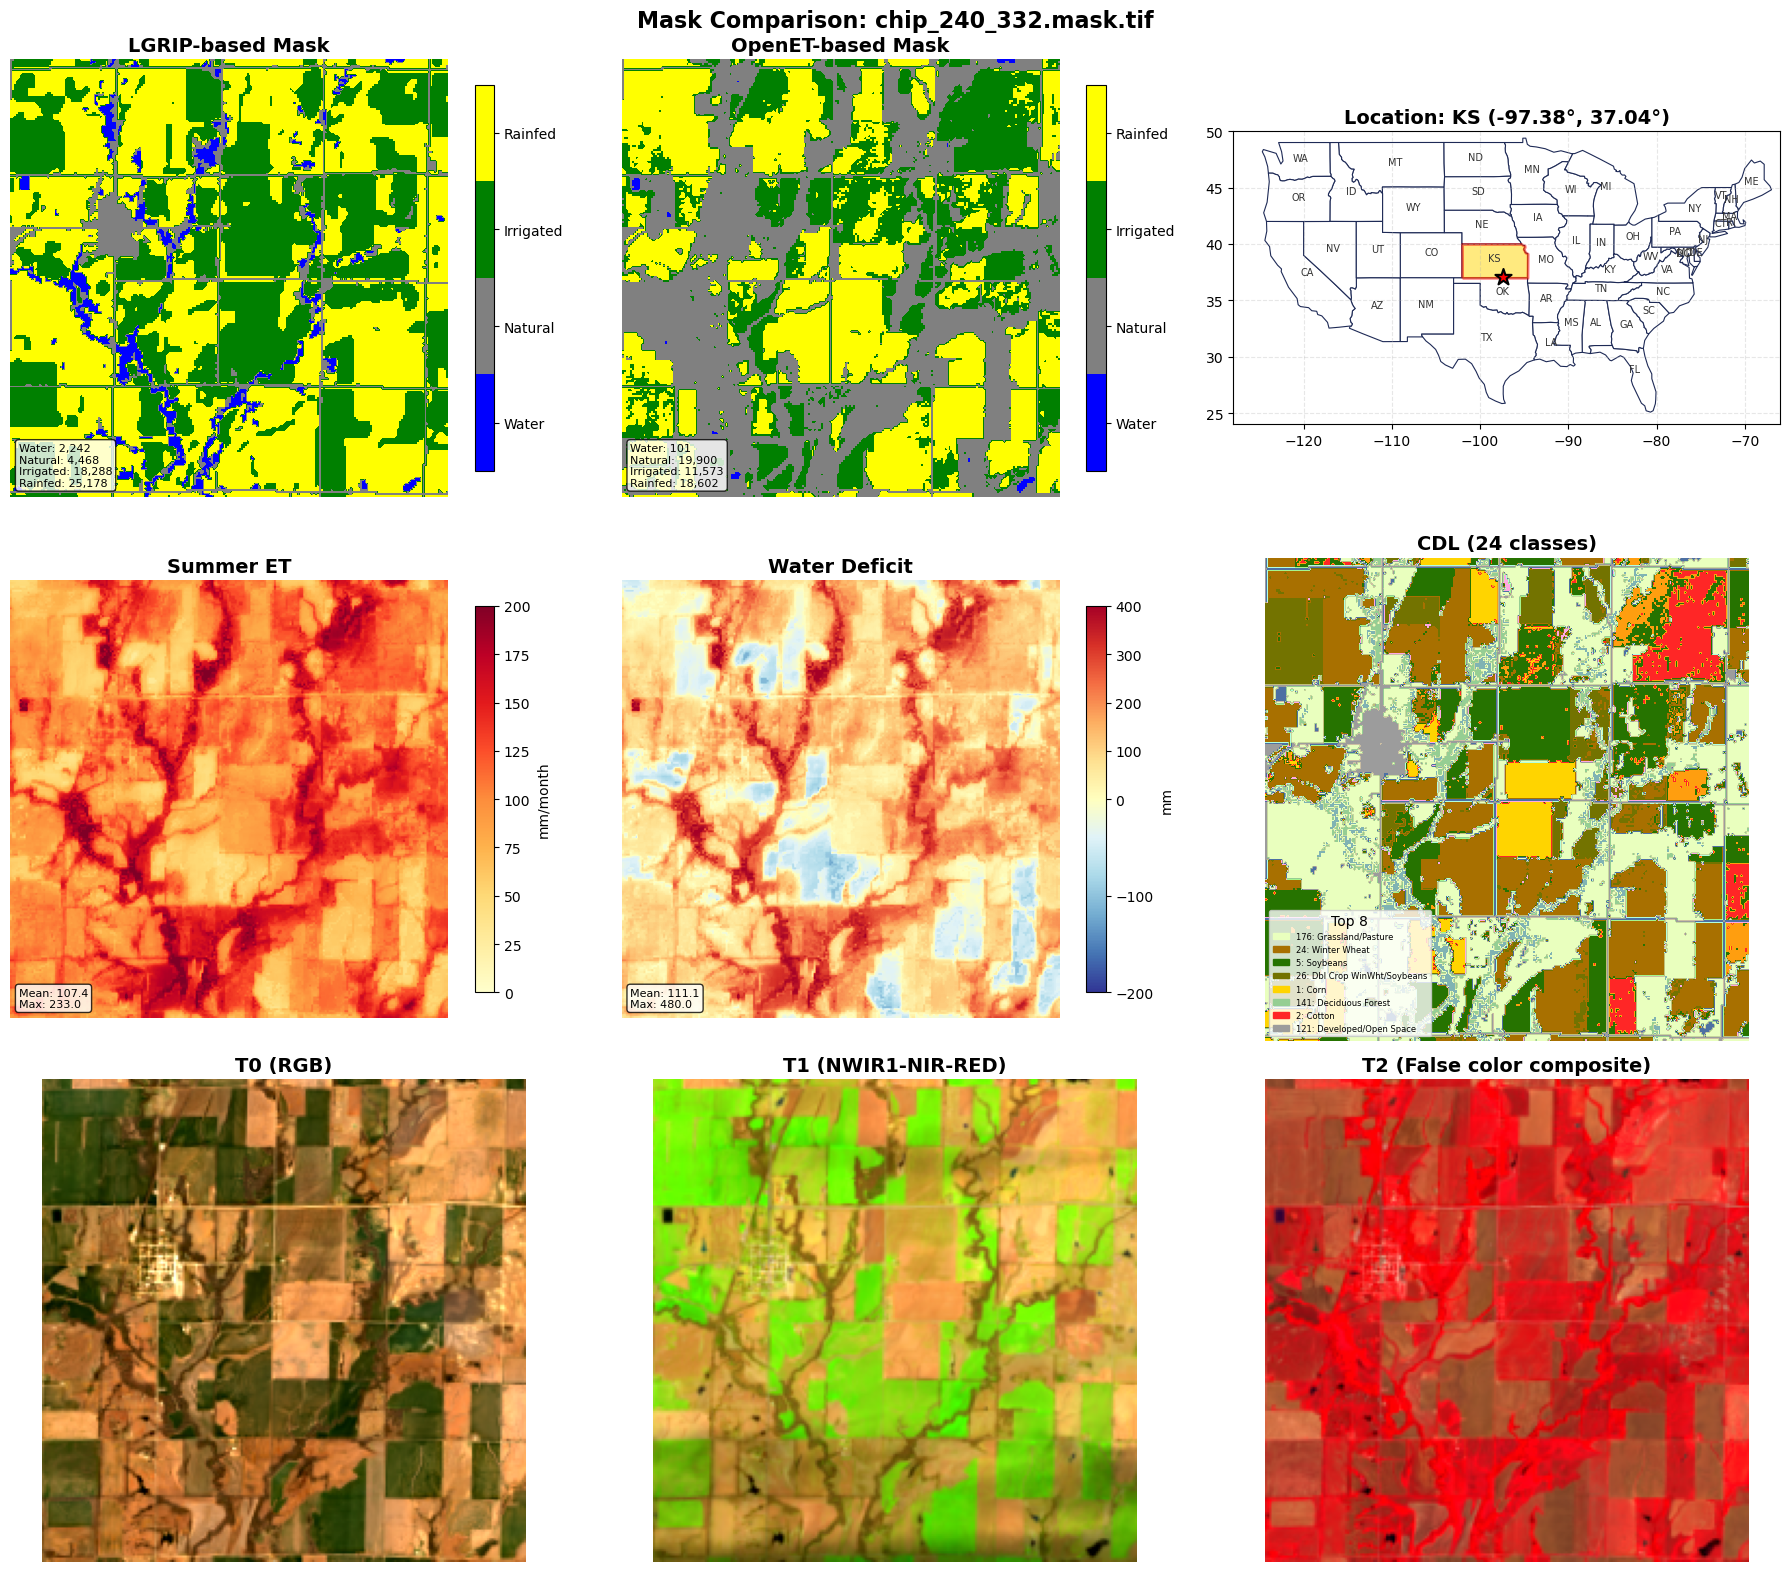

In [14]:
# ============== USAGE ==============
# Single chip
chip_num = 1600

openet_mask_dir = '/discover/nobackup/ejalilva/data/prithvi/openet_tiles_int_waterfixed_2022/ir_training_chips/'
lgrip_mask_dir = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_chips/'
chip_names = sorted(glob.glob(os.path.join(openet_mask_dir,'*.mask.tif')))
chip_name = chip_names[chip_num].split('/')[-1]
print(chip_name)

plot_mask_comparison(chip_name, lgrip_mask_dir, openet_mask_dir,lgrip_mask_dir,
                     save_path=f'comparison_{chip_name.split('.')[0]}.png')

In [40]:
# Check corn pixels showing as natural
corn_natural = (cdl_data == 1) & (label_data == 1)
print(f"Corn pixels classified as Natural: {corn_natural.sum()}")

if corn_natural.any():
    row, col = np.where(corn_natural)[0][0], np.where(corn_natural)[1][0]
    print(f"At pixel ({row},{col}):")
    print(f"  CDL: {cdl_data[row, col]}")
    print(f"  Label: {label_data[row, col]}")
    print(f"  ET: {et_data[row, col]}")
    print(f"  Deficit: {deficit_data[row, col]}")

Corn pixels classified as Natural: 0


In [41]:
# What CDL classes are in Natural areas?
natural_pixels = (label_data == 1)
cdl_at_natural = cdl_data[natural_pixels]
unique, counts = np.unique(cdl_at_natural, return_counts=True)
for u, c in sorted(zip(unique, counts), key=lambda x: -x[1])[:10]:
    print(f"CDL {int(u)}: {c} pixels")

CDL 190: 9702 pixels
CDL 141: 9151 pixels
CDL 121: 1702 pixels
CDL 176: 1551 pixels
CDL 122: 744 pixels
CDL 143: 296 pixels
CDL 195: 245 pixels
CDL 123: 189 pixels
CDL 142: 178 pixels
CDL 111: 107 pixels


In [43]:
unique_classes = np.unique(cdl_data[(~np.isnan(cdl_data)) & (cdl_data > 0)])
unique_classes = unique_classes.astype(int)